<a href="https://colab.research.google.com/github/vk460/uniprep_algorithm-/blob/main/Copy_of_algortihm_30_9_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, re, warnings, unicodedata, time
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")

OUT_DIR = "/content/uniprep_frozen_pipeline_output"
os.makedirs(OUT_DIR, exist_ok=True)

# >>> SET THIS to your actual file path before running Cell 1 <<<
RAW_PATH = "/content/uniprep_all_subjects_training.csv"

RAW_OVR = dict(
    year="Qyear", branch="branch", subject_code="subject_code",
    subject="subject", question_text="question_text",
    marks="mark_weightage", question_number="question_no",
    has_diagram="has_diagram", session=None,
)

EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# -- FROZEN constants, each tested before being frozen --
MIN_HISTORY = 3
MATCH_THR = 0.65
FROZEN_GROUPING_THRESHOLD = 0.70
FROZEN_GROUPING_LINKAGE = "average"
OCCURRENCE_WINDOW_YEARS = MIN_HISTORY
NEAR_THRESHOLD_BAND = 0.03

CORRECTED_FINAL_FEATURE_SET = [
    "occurrence_rate_fixed", "mean_marks", "diagram_probability",
    "group_cohesion", "representative_similarity",
    "position_compatibility", "mark_consistency",
]
# similarity_margin is intentionally excluded -- it needs the TARGET
# year's actual questions to compute, so it is kept only as a
# diagnostic column, never a model feature.

RF_PARAMS = {  # retained for research comparison only, not the live model
    "n_estimators": 300, "max_depth": 10, "min_samples_split": 4,
    "min_samples_leaf": 1, "class_weight": "balanced",
    "max_features": "sqrt", "random_state": 42, "n_jobs": -1,
}

KS = [1, 3, 5, 10, 16, 20, 30]
SEEDS = [42, 43, 44]

def log(m=""):
    print(m)

def section(title):
    log("\n" + "=" * 104 + f"\n{title}\n" + "=" * 104)

def save(df, name):
    df.to_csv(f"{OUT_DIR}/{name}", index=False)
    log(f"[saved] {name}  ({len(df)} rows)")

def pick(df, names, override=None):
    if override and override in df.columns:
        return override
    low = {c.lower(): c for c in df.columns}
    for n in names:
        if n.lower() in low:
            return low[n.lower()]
    return None

def norm_text(s):
    s = unicodedata.normalize("NFKC", str(s)).lower()
    s = re.sub(r"[\u200b-\u200f\ufeff]", "", s)
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

print("[Cell 0 OK]")

[Cell 0 OK]


In [ ]:
section("CELL 1 — DATA INGESTION")

if not os.path.exists(RAW_PATH):
    from google.colab import files
    up = files.upload()
    RAW_PATH = "/content/" + list(up)[0]

RAW = (
    pd.read_excel(RAW_PATH) if RAW_PATH.lower().endswith(("xlsx", "xls"))
    else pd.read_csv(RAW_PATH)
)
log(f"raw shape={RAW.shape}  columns={list(RAW.columns)}")

CMAP = dict(
    year=pick(RAW, ["year", "exam_year", "paper_year"], RAW_OVR["year"]),
    branch=pick(RAW, ["branch", "branch_name", "department"], RAW_OVR["branch"]),
    subject_code=pick(RAW, ["subject_code", "code", "course_code"], RAW_OVR["subject_code"]),
    subject=pick(RAW, ["subject", "subject_name", "course"], RAW_OVR["subject"]),
    question_text=pick(RAW, ["question_text", "question", "text"], RAW_OVR["question_text"]),
    marks=pick(RAW, ["marks", "mark"], RAW_OVR["marks"]),
    question_number=pick(RAW, ["question_number", "qno", "question_no"], RAW_OVR["question_number"]),
    has_diagram=pick(RAW, ["has_diagram", "diagram"], RAW_OVR["has_diagram"]),
    session=pick(RAW, ["session", "exam_session"], RAW_OVR["session"]),
)
for req in ("year", "question_text"):
    if CMAP[req] is None:
        raise RuntimeError(f"required column '{req}' not found -> set RAW_OVR['{req}']")
if not any(CMAP[k] for k in ("branch", "subject_code", "subject")):
    raise RuntimeError("need at least one scope column (branch/subject_code/subject)")

log(f"column mapping: {CMAP}")
print("[Cell 1 OK]")


CELL 1 — DATA INGESTION


Saving uniprep training dataset (2).xlsx to uniprep training dataset (2).xlsx
raw shape=(520, 11)  columns=['paper_id', 'branch', 'study_year', 'subject', 'subject_code', 'Qyear', 'question_no', 'sub_question', 'question_text', 'mark_weightage', 'has_diagram']
column mapping: {'year': 'Qyear', 'branch': 'branch', 'subject_code': 'subject_code', 'subject': 'subject', 'question_text': 'question_text', 'marks': 'mark_weightage', 'question_number': 'question_no', 'has_diagram': 'has_diagram', 'session': None}
[Cell 1 OK]


In [ ]:
section("CELL 2 — NORMALIZATION")

def _clean_str(s):
    return s.where(s.notna(), None).map(
        lambda v: None if v is None or str(v).strip().lower() in ("", "nan", "none", "na", "null")
        else str(v).strip()
    )

def standardize(raw, cmap):
    Q0 = pd.DataFrame({
        "year": pd.to_numeric(raw[cmap["year"]], errors="coerce"),
        "question_text": raw[cmap["question_text"]],
    })
    for k in ("branch", "subject_code", "subject", "question_number", "session"):
        Q0[k] = _clean_str(raw[cmap[k]]) if cmap[k] else None
    Q0["marks"] = pd.to_numeric(raw[cmap["marks"]], errors="coerce") if cmap["marks"] else np.nan
    if cmap["has_diagram"]:
        Q0["has_diagram"] = (
            raw[cmap["has_diagram"]].astype(str).str.strip().str.lower()
            .isin(["1", "true", "yes", "y", "t"]).astype(float)
        )
    else:
        Q0["has_diagram"] = np.nan
    return Q0

def parse_qno(s):
    if not isinstance(s, str):
        return np.nan, ""
    m = re.search(r"\d+", s)
    if not m:
        return np.nan, re.sub(r"[^a-z]", "", s.lower())
    return float(m.group()), re.sub(r"[^a-z]", "", s[m.end():].lower())

def _normalize_branch(v):
    if v is None:
        return ""
    return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", str(v)).strip().lower())

def _normalize_subject_code(v):
    if v is None:
        return ""
    s = unicodedata.normalize("NFKC", str(v))
    s = re.sub(r"\s+", "", s)
    s = re.sub(r"[\(\)\[\]\{\}]", "", s)
    return re.sub(r"[^A-Za-z0-9]", "", s)

def _normalize_subject_name(v):
    if v is None:
        return ""
    s = unicodedata.normalize("NFKC", str(v)).strip().lower()
    return re.sub(r"\s+", " ", s)

def normalize_data(Q0):
    Q = Q0.copy()
    bad_y = Q.year.isna() | (Q.year < 1990) | (Q.year > 2100)
    bad_t = Q.question_text.isna() | Q.question_text.astype(str).str.strip().isin(["", "nan", "None"])
    Q = Q[~(bad_y | bad_t)].copy()
    Q["year"] = Q.year.astype(int)
    Q["question_text"] = Q.question_text.astype(str).str.strip()

    Q["branch_n"] = Q.branch.map(_normalize_branch)
    Q["code_n"] = Q.subject_code.map(_normalize_subject_code)
    Q["subject_n"] = Q.subject.map(_normalize_subject_name)
    Q["ntext"] = Q.question_text.map(norm_text)

    pq = Q.question_number.map(parse_qno)
    Q["qmain"] = pq.map(lambda t: t[0])
    Q["qsub"] = pq.map(lambda t: t[1])

    # Scope: subject_code alone when a reliable code exists (already
    # course-unique). Branch is excluded -- the same subject_code was
    # found, in audit, under several inconsistent branch spellings
    # across years, which would re-fragment one real course into
    # several scopes if branch were included. Falls back to
    # branch+subject only when no code exists at all.
    has_code = (Q.code_n != "").mean() > 0.5
    Q["scope"] = Q.code_n if has_code else (Q.branch_n + "|" + Q.subject_n)

    has_q = Q.question_number.notna()
    dup = has_q & Q.duplicated(["scope", "year", "question_number", "ntext"], keep="first")
    Q = Q[~dup].reset_index(drop=True)

    Q["pos_norm"] = Q.qmain / Q.groupby(["year", "scope"]).qmain.transform("max")
    return Q

def validate_data(Q):
    ok = True
    if Q.scope.eq("").any():
        log("[WARN] some rows have an empty scope"); ok = False
    if Q.year.nunique() < MIN_HISTORY + 1:
        log(f"[WARN] only {Q.year.nunique()} years: need >= {MIN_HISTORY + 1}"); ok = False
    return ok

Q0 = standardize(RAW, CMAP)
Q = normalize_data(Q0)
validate_data(Q)
YEARS = sorted(Q.year.unique())
log(f"clean questions: {len(Q)} | years={YEARS} | scopes={Q.scope.nunique()}")
print("[Cell 2 OK]")



CELL 2 — NORMALIZATION
clean questions: 519 | years=[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)] | scopes=5
[Cell 2 OK]


In [ ]:
section("CELL 3 — EMBEDDINGS")

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(EMBED_MODEL)
train_embeddings = embedding_model.encode(
    Q["ntext"].tolist(), convert_to_numpy=True,
    normalize_embeddings=True, show_progress_bar=True,
)
train_embeddings = np.asarray(train_embeddings, dtype=np.float32)
if train_embeddings.shape[0] != len(Q):
    raise ValueError("Embedding row count does not match Q.")
log(f"embedding shape: {train_embeddings.shape}")
print("[Cell 3 OK]")


CELL 3 — EMBEDDINGS


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

embedding shape: (519, 384)
[Cell 3 OK]


In [ ]:
section("CELL 4 — FROZEN SEMANTIC GROUPING")
log(f"threshold={FROZEN_GROUPING_THRESHOLD}  linkage={FROZEN_GROUPING_LINKAGE}")

def build_frozen_semantic_groups(history_df, history_embeddings,
                                  threshold=FROZEN_GROUPING_THRESHOLD,
                                  linkage=FROZEN_GROUPING_LINKAGE):
    """
    Groups HISTORY ONLY. The caller must pass only rows from years
    before whatever year is being predicted.
    """
    required_cols = ["scope", "year", "ntext", "question_text"]
    missing = [c for c in required_cols if c not in history_df.columns]
    if missing:
        raise ValueError(f"history_df missing columns: {missing}")
    if len(history_df) != len(history_embeddings):
        raise ValueError("history_df / history_embeddings row mismatch.")

    history_df = history_df.reset_index(drop=True).copy()
    history_df["__pos"] = np.arange(len(history_df))

    group_rows, metadata_rows = [], []
    next_group_id = 0

    for scope_value, scope_rows in history_df.groupby("scope", sort=True):
        positions = scope_rows["__pos"].to_numpy()
        scope_embeddings = history_embeddings[positions]

        if len(scope_rows) == 1:
            labels = np.array([0])
        else:
            distance_threshold = 1.0 - threshold
            try:
                model = AgglomerativeClustering(
                    n_clusters=None, metric="cosine", linkage=linkage,
                    distance_threshold=distance_threshold,
                )
            except TypeError:
                model = AgglomerativeClustering(
                    n_clusters=None, affinity="cosine", linkage=linkage,
                    distance_threshold=distance_threshold,
                )
            labels = model.fit_predict(scope_embeddings)

        local_group_order = []
        for pos_local in range(len(scope_rows)):
            lbl = labels[pos_local]
            if lbl not in local_group_order:
                local_group_order.append(lbl)
        local_to_global = {lbl: next_group_id + i for i, lbl in enumerate(local_group_order)}
        next_group_id += len(local_group_order)

        global_ids = np.array([local_to_global[lbl] for lbl in labels])
        scope_rows = scope_rows.copy()
        scope_rows["group_id"] = global_ids
        group_rows.append(scope_rows)

        for lbl, global_id in local_to_global.items():
            member_mask = labels == lbl
            member_rows = scope_rows.iloc[np.where(member_mask)[0]]
            member_embeddings = scope_embeddings[member_mask]
            years = sorted(pd.to_numeric(member_rows["year"], errors="coerce").dropna().astype(int).unique())

            if len(member_embeddings) == 1:
                representative_idx = 0
            else:
                centroid = np.mean(member_embeddings, axis=0)
                norm = np.linalg.norm(centroid)
                centroid = centroid / norm if norm > 0 else centroid
                representative_idx = int(np.argmax(member_embeddings @ centroid))

            metadata_rows.append({
                "group_id": global_id, "scope": scope_value,
                "group_size": len(member_rows),
                "historical_years": ",".join(map(str, years)),
                "first_year": min(years) if years else None,
                "last_year": max(years) if years else None,
                "representative_question": member_rows.iloc[representative_idx]["question_text"],
            })

    grouped_df = pd.concat(group_rows, ignore_index=True).drop(columns=["__pos"])
    groups_summary = pd.DataFrame(metadata_rows)

    if groups_summary["group_size"].sum() != len(history_df):
        raise AssertionError("Group size accounting does not match history_df row count.")

    return grouped_df, groups_summary

# sanity check on full history (inspection only, not used as a fold)
_sanity_grouped, _sanity_summary = build_frozen_semantic_groups(Q, train_embeddings)
log(f"sanity check: {len(_sanity_summary)} groups from {len(Q)} historical questions")
print("[Cell 4 OK]")



CELL 4 — FROZEN SEMANTIC GROUPING
threshold=0.7  linkage=average
sanity check: 278 groups from 519 historical questions
[Cell 4 OK]


In [ ]:
section("CELL 5 — CANDIDATE GENERATION")
log("Frozen strategy: A0_baseline -- every semantic group is a candidate, no filter.")
log("Tested against semantic_cohesion / top_n_per_scope / recurrence_rule / hybrid;")
log("A0 won because every filter traded away real, unrecoverable candidates for only")
log("a small noise reduction. No code needed here -- this cell is a record of the")
log("decision; nothing filters the candidate pool downstream.")
print("[Cell 5 OK]")


CELL 5 — CANDIDATE GENERATION
Frozen strategy: A0_baseline -- every semantic group is a candidate, no filter.
Tested against semantic_cohesion / top_n_per_scope / recurrence_rule / hybrid;
A0 won because every filter traded away real, unrecoverable candidates for only
a small noise reduction. No code needed here -- this cell is a record of the
decision; nothing filters the candidate pool downstream.
[Cell 5 OK]


In [ ]:

section("CELL 6 — FEATURE ENGINEERING")

def build_features_and_labels(Q, train_embeddings, validation_year):
    """
    Returns the feature table for one validation year: the 7
    production features, the near-threshold training flag, and the
    GROUP-CENTRIC label (each group judged by its own best match to
    any actual question, independent of other groups).

    similarity_margin is computed and kept as a DIAGNOSTIC column
    only -- it needs the actual validation-year questions, so it
    must never be used as a model feature (that would leak the
    answer; found and fixed during development).
    """
    history_mask = (Q["year"] < validation_year).to_numpy()
    actual_mask = (Q["year"] == validation_year).to_numpy()
    history_positions = np.where(history_mask)[0]
    actual_positions = np.where(actual_mask)[0]
    if len(history_positions) == 0 or len(actual_positions) == 0:
        return None

    history_df_year = Q.iloc[history_positions].copy()
    history_embeddings_year = train_embeddings[history_positions]
    actual_df_year = Q.iloc[actual_positions].copy()
    actual_embeddings_year = train_embeddings[actual_positions]

    grouped_df, groups_summary = build_frozen_semantic_groups(history_df_year, history_embeddings_year)
    group_ids_local = grouped_df["group_id"].to_numpy()
    window_start = validation_year - OCCURRENCE_WINDOW_YEARS

    feature_rows = []
    for group_id in groups_summary["group_id"]:
        member_positions = np.flatnonzero(group_ids_local == group_id)
        member = grouped_df.iloc[member_positions]
        member_embeddings = history_embeddings_year[member_positions]

        years = sorted(pd.to_numeric(member["year"], errors="coerce").dropna().astype(int).unique().tolist())
        years_in_window = [y for y in years if y >= window_start]
        occurrence_rate_fixed = len(set(years_in_window)) / OCCURRENCE_WINDOW_YEARS

        marks = pd.to_numeric(member["marks"], errors="coerce").dropna().to_numpy()
        mean_marks = float(np.mean(marks)) if len(marks) else np.nan
        mark_consistency = float(1.0 / (1.0 + np.std(marks))) if len(marks) else np.nan

        diagrams = pd.to_numeric(member["has_diagram"], errors="coerce").dropna().to_numpy()
        diagram_probability = float(np.mean(diagrams)) if len(diagrams) else np.nan

        pos = pd.to_numeric(member["pos_norm"], errors="coerce").dropna().to_numpy()
        position_compatibility = float(1.0 / (1.0 + np.std(pos))) if len(pos) else np.nan

        if len(member_embeddings) == 1:
            group_cohesion, representative_similarity = 1.0, 1.0
        else:
            sim_matrix = cosine_similarity(member_embeddings)
            upper = sim_matrix[np.triu_indices(len(member_embeddings), k=1)]
            group_cohesion = float(np.mean(upper)) if len(upper) else 1.0
            centroid = np.mean(member_embeddings, axis=0)
            norm = np.linalg.norm(centroid)
            centroid = centroid / norm if norm > 0 else centroid
            representative_similarity = float(np.max(member_embeddings @ centroid))

        feature_rows.append({
            "group_id": group_id, "scope": member["scope"].iloc[0],
            "validation_year": validation_year,
            "occurrence_rate_fixed": occurrence_rate_fixed,
            "mean_marks": mean_marks, "mark_consistency": mark_consistency,
            "diagram_probability": diagram_probability,
            "position_compatibility": position_compatibility,
            "group_cohesion": group_cohesion,
            "representative_similarity": representative_similarity,
        })

    features_df = pd.DataFrame(feature_rows)

    rows = []
    for scope_value, scope_actual in actual_df_year.groupby("scope"):
        scope_actual_positions_local = np.where(actual_df_year["scope"].to_numpy() == scope_value)[0]
        scope_actual_embeddings = actual_embeddings_year[scope_actual_positions_local]
        scope_group_ids = sorted(groups_summary.loc[groups_summary["scope"] == scope_value, "group_id"])
        if not scope_group_ids or len(scope_actual_embeddings) == 0:
            for gid in scope_group_ids:
                rows.append({"group_id": gid, "best_similarity_to_actual": 0.0, "similarity_margin": 0.0})
            continue

        group_sim_matrix = np.zeros((len(scope_group_ids), len(scope_actual_embeddings)))
        for gi, gid in enumerate(scope_group_ids):
            member_positions = np.flatnonzero(group_ids_local == gid)
            member_embeddings = history_embeddings_year[member_positions]
            sims = cosine_similarity(member_embeddings, scope_actual_embeddings)
            group_sim_matrix[gi, :] = sims.max(axis=0)

        for gi, gid in enumerate(scope_group_ids):
            own_row = group_sim_matrix[gi, :]
            best_idx = int(np.argmax(own_row))
            best_sim = float(own_row[best_idx])
            column = group_sim_matrix[:, best_idx].copy()
            column[gi] = -np.inf
            best_other = float(np.max(column)) if len(column) > 1 else 0.0
            rows.append({
                "group_id": gid, "best_similarity_to_actual": best_sim,
                "similarity_margin": best_sim - best_other,  # DIAGNOSTIC ONLY
            })

    label_info = pd.DataFrame(rows)
    features_df = features_df.merge(label_info, on="group_id", how="left")
    features_df["label"] = (features_df["best_similarity_to_actual"] >= MATCH_THR).astype(int)
    features_df["near_threshold_label"] = (
        (features_df["best_similarity_to_actual"] >= MATCH_THR - NEAR_THRESHOLD_BAND)
        & (features_df["best_similarity_to_actual"] <= MATCH_THR + NEAR_THRESHOLD_BAND)
    )
    return features_df

_valid_validation_years = [y for i, y in enumerate(YEARS) if i >= MIN_HISTORY]
_tables = []
for vy in _valid_validation_years:
    t = build_features_and_labels(Q, train_embeddings, vy)
    if t is None:
        continue
    _tables.append(t)
    log(f"[{vy}] candidates={len(t)}  positive={int(t['label'].sum())}  "
        f"near_threshold={int(t['near_threshold_label'].sum())}")

FEATURE_MASTER_TABLE = pd.concat(_tables, ignore_index=True)
missing = [c for c in CORRECTED_FINAL_FEATURE_SET if c not in FEATURE_MASTER_TABLE.columns]
if missing:
    raise AssertionError(f"Feature master table missing: {missing}")

save(FEATURE_MASTER_TABLE, "feature_master_table.csv")
display(FEATURE_MASTER_TABLE.head(10))
print("[Cell 6 OK]")



CELL 6 — FEATURE ENGINEERING
[2024] candidates=214  positive=33  near_threshold=7
[2025] candidates=246  positive=51  near_threshold=16
[saved] feature_master_table.csv  (460 rows)


,group_id,scope,validation_year,occurrence_rate_fixed,mean_marks,mark_consistency,diagram_probability,position_compatibility,group_cohesion,representative_similarity,best_similarity_to_actual,similarity_margin,label,near_threshold_label
0,0,210242,2024,0.666667,9.0,1.0,0.0,1.000000,0.003299,0.708272,0.658112,0.201541,1,True
1,1,210242,2024,0.666667,9.0,1.0,0.0,0.944353,0.327958,0.824940,0.683157,0.296870,1,False
2,2,210242,2024,0.666667,9.0,1.0,0.0,0.941176,0.221981,0.781659,0.509833,0.156978,0,False
3,3,210242,2024,0.333333,9.0,1.0,0.0,1.000000,1.000000,1.000000,0.676486,0.044611,1,True
4,4,210242,2024,0.666667,9.0,1.0,0.0,0.941176,0.162046,0.762249,0.548906,-0.144963,0,False
5,5,210242,2024,0.333333,9.0,1.0,0.0,1.000000,1.000000,1.000000,0.693869,0.105573,1,False
6,6,210242,2024,0.666667,9.0,1.0,0.0,1.000000,0.205865,0.776488,0.631874,-0.044611,0,True
7,7,210242,2024,0.333333,8.0,1.0,0.0,1.000000,1.000000,1.000000,0.634049,-0.055509,0,True
8,8,210242,2024,1.000000,9.0,1.0,0.0,1.000000,0.182868,0.722931,0.713334,0.270178,1,False
9,9,210242,2024,0.666667,8.0,1.0,0.0,1.000000,-0.036649,0.694028,0.756558,0.237525,1,False


[Cell 6 OK]


In [ ]:
section("CELL 6b — RF COMPARISON MODEL (not used in the live path)")

def train_and_score_rf(train_df, test_df, feature_columns=CORRECTED_FINAL_FEATURE_SET):
    """Kept only so the RF baseline remains reproducible for research
    comparison. NOT part of the live/frozen prediction path -- the
    frozen model is the pairwise ranker in Cell 7."""
    X_train = train_df[feature_columns].apply(pd.to_numeric, errors="coerce")
    y_train = train_df["label"].to_numpy()
    X_test = test_df[feature_columns].apply(pd.to_numeric, errors="coerce")
    medians = X_train.median().fillna(0.0)
    X_train, X_test = X_train.fillna(medians).fillna(0.0), X_test.fillna(medians).fillna(0.0)
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_train, y_train)
    classes = list(model.classes_)
    return model.predict_proba(X_test)[:, classes.index(1)] if 1 in classes else np.zeros(len(X_test))

log("train_and_score_rf() defined. Call it manually if you want the RF comparison")
log("reproduced for your report -- it is not called automatically.")
print("[Cell 6b OK]")


CELL 6b — RF COMPARISON MODEL (not used in the live path)
train_and_score_rf() defined. Call it manually if you want the RF comparison
reproduced for your report -- it is not called automatically.
[Cell 6b OK]


In [ ]:
section("CELL 7 — PAIRWISE RANKER")

def train_pairwise_ranker(train_df, feature_columns=CORRECTED_FINAL_FEATURE_SET, seed=SEEDS[0]):
    """Trained only on within-scope pairs. A linear model trained on
    pairwise differences can be scored on individual candidates at
    inference time with the same weight vector."""
    X_raw = train_df[feature_columns].apply(pd.to_numeric, errors="coerce")
    medians = X_raw.median().fillna(0.0)
    X_raw = X_raw.fillna(medians).fillna(0.0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    train_df = train_df.reset_index(drop=True)
    diffs, pair_labels = [], []
    for scope_value, scope_rows in train_df.groupby("scope"):
        idx = scope_rows.index.to_numpy()
        pos_idx = idx[scope_rows["label"].to_numpy() == 1]
        neg_idx = idx[scope_rows["label"].to_numpy() == 0]
        if len(pos_idx) == 0 or len(neg_idx) == 0:
            continue
        for p in pos_idx:
            for n in neg_idx:
                diffs.append(X_scaled[p] - X_scaled[n]); pair_labels.append(1)
                diffs.append(X_scaled[n] - X_scaled[p]); pair_labels.append(0)

    if not diffs:
        raise RuntimeError("No scope had both a positive and a negative candidate for pairwise training.")

    X_pairs, y_pairs = np.vstack(diffs), np.array(pair_labels)
    model = LogisticRegression(fit_intercept=False, max_iter=2000, random_state=seed)
    model.fit(X_pairs, y_pairs)
    return model, scaler, medians

def score_pairwise(model, scaler, medians, test_df, feature_columns=CORRECTED_FINAL_FEATURE_SET):
    X_raw = test_df[feature_columns].apply(pd.to_numeric, errors="coerce")
    X_raw = X_raw.fillna(medians).fillna(0.0)
    X_scaled = scaler.transform(X_raw)
    return X_scaled @ model.coef_[0]

def tie_diagnostic(ranking_df, feature_columns=CORRECTED_FINAL_FEATURE_SET):
    """REQUIRED before trusting the ranker: checks whether tied
    scores come from genuinely identical feature vectors (expected,
    benign) or something else (investigate before production use)."""
    section("TIE DIAGNOSTIC (required before freeze)")
    n_unique_scores = ranking_df["pairwise_score"].nunique()
    n_total = len(ranking_df)
    log(f"Unique ranking scores: {n_unique_scores} of {n_total} candidates.")

    tie_groups = (
        ranking_df.groupby("pairwise_score")
        .agg(tie_size=("group_id", "count"), positives=("label", "sum"))
        .reset_index().query("tie_size > 1")
        .sort_values("tie_size", ascending=False)
    )

    dup_feature_vectors = ranking_df.duplicated(subset=feature_columns, keep=False)
    log(f"Candidates with an exact duplicate 7-feature vector: {int(dup_feature_vectors.sum())} of {n_total}")

    if not tie_groups.empty:
        consistent = True
        for score_val, group in ranking_df[ranking_df["pairwise_score"].isin(tie_groups["pairwise_score"])].groupby("pairwise_score"):
            if group[feature_columns].drop_duplicates().shape[0] > 1:
                consistent = False
        log(f"All tied scores correspond to identical feature vectors: {consistent}")
        if not consistent:
            log("⚠ WARNING: some ties are NOT explained by identical feature vectors. "
                "Investigate before trusting this ranker in production.")
    else:
        log("No ties found.")
    return tie_groups, dup_feature_vectors


train_year, test_year = _valid_validation_years[-2], _valid_validation_years[-1]
log(f"train={train_year}  evaluate={test_year}")

train_df = FEATURE_MASTER_TABLE[
    (FEATURE_MASTER_TABLE["validation_year"] == train_year)
    & (~FEATURE_MASTER_TABLE["near_threshold_label"])
].copy()
test_df = FEATURE_MASTER_TABLE[FEATURE_MASTER_TABLE["validation_year"] == test_year].copy()

pairwise_model, scaler, medians = train_pairwise_ranker(train_df)
test_df["pairwise_score"] = score_pairwise(pairwise_model, scaler, medians, test_df)

tie_groups, dup_vectors = tie_diagnostic(test_df)
save(tie_groups, "tie_diagnostic.csv")
print("[Cell 7 OK]")


CELL 7 — PAIRWISE RANKER
train=2024  evaluate=2025

TIE DIAGNOSTIC (required before freeze)
Unique ranking scores: 123 of 246 candidates.
Candidates with an exact duplicate 7-feature vector: 138 of 246
All tied scores correspond to identical feature vectors: True
[saved] tie_diagnostic.csv  (15 rows)
[Cell 7 OK]


In [ ]:
section("CELL 8 — SELECTION")

def historical_target_count(Q, scope_value, before_year):
    history = Q[(Q["scope"] == scope_value) & (Q["year"] < before_year)]
    if history.empty:
        return 0
    per_year_counts = history.groupby("year").size()
    return max(1, int(round(per_year_counts.median()))) if len(per_year_counts) else 0

def select_top_k(Q, ranking_df, validation_year, score_column="pairwise_score"):
    scope_rows_out, selected_rows_out = [], []
    for scope_value, scope_ranking in ranking_df.groupby("scope"):
        target_count = historical_target_count(Q, scope_value, validation_year)
        scope_sorted = scope_ranking.sort_values(score_column, ascending=False).reset_index(drop=True)
        selected = scope_sorted.head(target_count)
        positive_count = int(scope_ranking["label"].sum())
        oracle_selected = min(positive_count, target_count)
        actual_selected_positive = int(selected["label"].sum())
        scope_rows_out.append({
            "scope": scope_value, "candidate_count": len(scope_ranking),
            "positive_count": positive_count, "target_count": target_count,
            "oracle_selected": oracle_selected,
            "actual_selected_positive": actual_selected_positive,
            "ranking_loss": oracle_selected - actual_selected_positive,
            "budget_loss": max(0, positive_count - target_count),
        })
        selected_rows_out.append(selected)
    return pd.DataFrame(scope_rows_out), pd.concat(selected_rows_out, ignore_index=True)

scope_df, selected_df = select_top_k(Q, test_df, test_year)
save(scope_df, "selection_scope_detail.csv")
save(selected_df, "final_predicted_paper.csv")
display(scope_df)
print("[Cell 8 OK]")



CELL 8 — SELECTION
[saved] selection_scope_detail.csv  (5 rows)
[saved] final_predicted_paper.csv  (106 rows)


,scope,candidate_count,positive_count,target_count,oracle_selected,actual_selected_positive,ranking_loss,budget_loss
0,210242,40,9,16,9,6,3,0
1,210243,56,15,24,15,10,5,0
2,210253,58,0,18,0,0,0,0
3,210254,39,16,24,16,14,2,0
4,210255,53,11,24,11,10,1,0


[Cell 8 OK]


In [ ]:
section("CELL 9 — EVALUATION")

def evaluate(ranking_df, scope_df, score_column="pairwise_score"):
    y_test = ranking_df["label"].to_numpy()
    scores = ranking_df[score_column].to_numpy()
    positive_total = int(y_test.sum())

    ranking_sorted = ranking_df.sort_values(score_column, ascending=False).reset_index(drop=True)
    topk = {
        f"top_{k}_recall": int(ranking_sorted.head(k)["label"].sum()) / positive_total if positive_total else np.nan
        for k in KS
    }

    total_positive = scope_df["positive_count"].sum()
    total_oracle = scope_df["oracle_selected"].sum()
    total_actual = scope_df["actual_selected_positive"].sum()

    return {
        "roc_auc": roc_auc_score(y_test, scores) if len(np.unique(y_test)) == 2 else np.nan,
        "pr_auc": average_precision_score(y_test, scores),
        **topk,
        "oracle_recall": total_oracle / total_positive if total_positive else np.nan,
        "actual_recall": total_actual / total_positive if total_positive else np.nan,
        "ranking_loss_total": int(scope_df["ranking_loss"].sum()),
        "budget_loss_total": int(scope_df["budget_loss"].sum()),
    }

metrics = evaluate(test_df, scope_df)
metrics_df = pd.DataFrame([metrics])
save(metrics_df, "final_evaluation_metrics.csv")

section("FINAL RESULT")
log(f"Pairwise ranker, {train_year}->{test_year}, single strict OOS fold:")
for k, v in metrics.items():
    log(f"  {k}: {v}")
log("\n⚠ Single strict OOS fold — directional evidence, not statistical proof.")

display(metrics_df)
print("[Cell 9 OK — pipeline complete]")


CELL 9 — EVALUATION
[saved] final_evaluation_metrics.csv  (1 rows)

FINAL RESULT
Pairwise ranker, 2024->2025, single strict OOS fold:
  roc_auc: 0.6233283056812469
  pr_auc: 0.2608830200543567
  top_1_recall: 0.0
  top_3_recall: 0.0196078431372549
  top_5_recall: 0.0196078431372549
  top_10_recall: 0.0196078431372549
  top_16_recall: 0.0392156862745098
  top_20_recall: 0.0784313725490196
  top_30_recall: 0.17647058823529413
  oracle_recall: 1.0
  actual_recall: 0.7843137254901961
  ranking_loss_total: 11
  budget_loss_total: 0

⚠ Single strict OOS fold — directional evidence, not statistical proof.


,roc_auc,pr_auc,top_1_recall,top_3_recall,top_5_recall,top_10_recall,top_16_recall,top_20_recall,top_30_recall,oracle_recall,actual_recall,ranking_loss_total,budget_loss_total
0,0.623328,0.260883,0.0,0.019608,0.019608,0.019608,0.039216,0.078431,0.176471,1.0,0.784314,11,0


[Cell 9 OK — pipeline complete]


In [ ]:
# ============================================================
# CELL 10 — FINAL 2026 OUT-OF-SAMPLE TEST
# ============================================================

section("CELL 10 — FINAL 2026 OUT-OF-SAMPLE TEST")

# ------------------------------------------------------------
# IMPORTANT:
# This cell DOES NOT modify the frozen algorithm.
#
# Training:
#   Historical folds 2024 and 2025
#
# Final test:
#   2026
#
# 2026 questions are NOT used while training the ranker.
# ------------------------------------------------------------

FINAL_TEST_YEAR = 2026

# Change ONLY this path if your actual 2026 testing CSV has
# another filename.
FINAL_TEST_PATH = "/content/uniprep testing dataset (2).csv"


# ============================================================
# 10.1 LOAD 2026 TEST DATA
# ============================================================

if not os.path.exists(FINAL_TEST_PATH):
    raise FileNotFoundError(
        f"""
2026 testing file not found:

{FINAL_TEST_PATH}

Please upload your actual 2026 testing CSV or change
FINAL_TEST_PATH to the correct file.
"""
    )

TEST_RAW = (
    pd.read_excel(FINAL_TEST_PATH)
    if FINAL_TEST_PATH.lower().endswith(("xlsx", "xls"))
    else pd.read_csv(FINAL_TEST_PATH)
)

log(f"2026 raw shape = {TEST_RAW.shape}")
log(f"2026 columns = {list(TEST_RAW.columns)}")


# ============================================================
# 10.2 STANDARDIZE 2026 DATA USING THE SAME MAPPING
# ============================================================

TEST_Q0 = standardize(TEST_RAW, CMAP)

TEST_Q = normalize_data(TEST_Q0)

log(f"2026 cleaned questions = {len(TEST_Q)}")
log(f"2026 years found = {sorted(TEST_Q['year'].unique())}")
log(f"2026 scopes = {TEST_Q['scope'].nunique()}")


if FINAL_TEST_YEAR not in TEST_Q["year"].unique():
    raise ValueError(
        f"Expected 2026 data, but 2026 was not found. "
        f"Available years: {sorted(TEST_Q['year'].unique())}"
    )


# Only keep the final test year.
TEST_2026 = TEST_Q[
    TEST_Q["year"] == FINAL_TEST_YEAR
].copy().reset_index(drop=True)

log(f"2026 actual questions = {len(TEST_2026)}")


# ============================================================
# 10.3 EMBED 2026 QUESTIONS
# ============================================================

# IMPORTANT:
# This does NOT train the embedding model.
# The already frozen pretrained embedding model is only
# used to transform 2026 questions into vectors.

test_embeddings = embedding_model.encode(
    TEST_2026["ntext"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True,
)

test_embeddings = np.asarray(test_embeddings, dtype=np.float32)

if len(test_embeddings) != len(TEST_2026):
    raise ValueError(
        "2026 embedding count does not match 2026 question count."
    )

log(f"2026 embedding shape = {test_embeddings.shape}")


# ============================================================
# 10.4 BUILD 2026 HISTORY
# ============================================================

# VERY IMPORTANT:
# Only years BEFORE 2026 are allowed here.
#
# 2026 is NEVER included in the history.

HISTORY_2026 = Q[
    Q["year"] < FINAL_TEST_YEAR
].copy().reset_index(drop=True)

history_indices = np.where(
    Q["year"].to_numpy() < FINAL_TEST_YEAR
)[0]

history_embeddings_2026 = train_embeddings[history_indices]

log(f"2026 historical questions = {len(HISTORY_2026)}")
log(
    f"2026 historical years = "
    f"{sorted(HISTORY_2026['year'].unique())}"
)


if HISTORY_2026["year"].nunique() < MIN_HISTORY:
    raise RuntimeError(
        "Insufficient historical years for final 2026 prediction."
    )


# ============================================================
# 10.5 BUILD HISTORY-ONLY SEMANTIC GROUPS
# ============================================================

GROUPED_2026, GROUPS_2026 = build_frozen_semantic_groups(
    HISTORY_2026,
    history_embeddings_2026,
    threshold=FROZEN_GROUPING_THRESHOLD,
    linkage=FROZEN_GROUPING_LINKAGE,
)

log(
    f"2026 history-only groups = {len(GROUPS_2026)}"
)

log(
    f"2026 history questions accounted for = "
    f"{GROUPS_2026['group_size'].sum()}"
)


if GROUPS_2026["group_size"].sum() != len(HISTORY_2026):
    raise AssertionError(
        "2026 grouping accounting error."
    )


# ============================================================
# 10.6 BUILD LEAKAGE-FREE 2026 CANDIDATE FEATURES
# ============================================================

def build_final_test_features(
    history_df,
    history_embeddings,
    groups_summary,
    grouped_df,
):
    """
    Build ONLY historical features for final 2026 prediction.

    IMPORTANT:
    No 2026 question is used here.

    Therefore:
        - no 2026 labels
        - no similarity to actual 2026 questions
        - no similarity_margin
        - no future information
    """

    feature_rows = []

    group_ids = grouped_df["group_id"].to_numpy()

    for group_id in groups_summary["group_id"]:

        member_positions = np.flatnonzero(
            group_ids == group_id
        )

        member = grouped_df.iloc[
            member_positions
        ].copy()

        member_embeddings = history_embeddings[
            member_positions
        ]

        # --------------------------------------------
        # Historical recurrence
        # --------------------------------------------

        years = sorted(
            pd.to_numeric(
                member["year"],
                errors="coerce"
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        )

        window_start = (
            FINAL_TEST_YEAR
            - OCCURRENCE_WINDOW_YEARS
        )

        years_in_window = [
            y for y in years
            if y >= window_start
        ]

        occurrence_rate_fixed = (
            len(set(years_in_window))
            / OCCURRENCE_WINDOW_YEARS
        )

        # --------------------------------------------
        # Marks
        # --------------------------------------------

        marks = pd.to_numeric(
            member["marks"],
            errors="coerce"
        ).dropna().to_numpy()

        mean_marks = (
            float(np.mean(marks))
            if len(marks)
            else np.nan
        )

        mark_consistency = (
            float(
                1.0 /
                (1.0 + np.std(marks))
            )
            if len(marks)
            else np.nan
        )

        # --------------------------------------------
        # Diagram
        # --------------------------------------------

        diagrams = pd.to_numeric(
            member["has_diagram"],
            errors="coerce"
        ).dropna().to_numpy()

        diagram_probability = (
            float(np.mean(diagrams))
            if len(diagrams)
            else np.nan
        )

        # --------------------------------------------
        # Position
        # --------------------------------------------

        pos = pd.to_numeric(
            member["pos_norm"],
            errors="coerce"
        ).dropna().to_numpy()

        position_compatibility = (
            float(
                1.0 /
                (1.0 + np.std(pos))
            )
            if len(pos)
            else np.nan
        )

        # --------------------------------------------
        # Semantic group quality
        # --------------------------------------------

        if len(member_embeddings) == 1:

            group_cohesion = 1.0
            representative_similarity = 1.0

        else:

            sim_matrix = cosine_similarity(
                member_embeddings
            )

            upper = sim_matrix[
                np.triu_indices(
                    len(member_embeddings),
                    k=1
                )
            ]

            group_cohesion = (
                float(np.mean(upper))
                if len(upper)
                else 1.0
            )

            centroid = np.mean(
                member_embeddings,
                axis=0
            )

            norm = np.linalg.norm(
                centroid
            )

            centroid = (
                centroid / norm
                if norm > 0
                else centroid
            )

            representative_similarity = float(
                np.max(
                    member_embeddings @ centroid
                )
            )

        feature_rows.append({

            "group_id": group_id,

            "scope": member["scope"].iloc[0],

            "occurrence_rate_fixed":
                occurrence_rate_fixed,

            "mean_marks":
                mean_marks,

            "diagram_probability":
                diagram_probability,

            "group_cohesion":
                group_cohesion,

            "representative_similarity":
                representative_similarity,

            "position_compatibility":
                position_compatibility,

            "mark_consistency":
                mark_consistency,

        })

    return pd.DataFrame(feature_rows)


FINAL_2026_FEATURES = build_final_test_features(
    HISTORY_2026,
    history_embeddings_2026,
    GROUPS_2026,
    GROUPED_2026,
)


missing_final_features = [
    c for c in CORRECTED_FINAL_FEATURE_SET
    if c not in FINAL_2026_FEATURES.columns
]

if missing_final_features:
    raise AssertionError(
        f"Missing final-test features: "
        f"{missing_final_features}"
    )


log(
    f"2026 candidate groups = "
    f"{len(FINAL_2026_FEATURES)}"
)


# ============================================================
# 10.7 TRAIN FINAL RANKER USING HISTORICAL WALK-FORWARD DATA
# ============================================================

# We DO NOT use 2026 labels.
#
# Available supervised folds:
#
# 2024:
#     history = 2021-2023
#     validation = 2024
#
# 2025:
#     history = 2021-2024
#     validation = 2025
#
# These become the training examples for the final ranker.

FINAL_RANKER_TRAIN = FEATURE_MASTER_TABLE[
    FEATURE_MASTER_TABLE["validation_year"].isin(
        [2024, 2025]
    )
    &
    (~FEATURE_MASTER_TABLE["near_threshold_label"])
].copy()


log(
    f"Final ranker training rows = "
    f"{len(FINAL_RANKER_TRAIN)}"
)

log(
    f"Training validation years = "
    f"{sorted(FINAL_RANKER_TRAIN['validation_year'].unique())}"
)

log(
    f"Training positives = "
    f"{int(FINAL_RANKER_TRAIN['label'].sum())}"
)

log(
    f"Training negatives = "
    f"{int((FINAL_RANKER_TRAIN['label'] == 0).sum())}"
)


# Train final pairwise model.
FINAL_PAIRWISE_MODEL, FINAL_SCALER, FINAL_MEDIANS = (
    train_pairwise_ranker(
        FINAL_RANKER_TRAIN,
        feature_columns=CORRECTED_FINAL_FEATURE_SET,
        seed=SEEDS[0],
    )
)


# ============================================================
# 10.8 SCORE 2026 CANDIDATES
# ============================================================

FINAL_2026_FEATURES["pairwise_score"] = (
    score_pairwise(
        FINAL_PAIRWISE_MODEL,
        FINAL_SCALER,
        FINAL_MEDIANS,
        FINAL_2026_FEATURES,
        feature_columns=CORRECTED_FINAL_FEATURE_SET,
    )
)


# ============================================================
# 10.9 HISTORICAL TARGET COUNT
# ============================================================

FINAL_2026_FEATURES["target_count"] = (
    FINAL_2026_FEATURES["scope"]
    .map(
        FINAL_2026_FEATURES["scope"].map(
            lambda s: historical_target_count(
                Q,
                s,
                FINAL_TEST_YEAR
            )
        )
    )
)


# The expression above can be simplified/recomputed safely.
target_map = {}

for scope_value in FINAL_2026_FEATURES["scope"].unique():

    target_map[scope_value] = historical_target_count(
        Q,
        scope_value,
        FINAL_TEST_YEAR
    )

FINAL_2026_FEATURES["target_count"] = (
    FINAL_2026_FEATURES["scope"]
    .map(target_map)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 10.10 SELECT FINAL 2026 PREDICTIONS
# ============================================================

selected_2026 = []

scope_test_details = []

for scope_value, scope_rows in (
    FINAL_2026_FEATURES.groupby("scope")
):

    target_count = int(
        target_map.get(
            scope_value,
            0
        )
    )

    scope_sorted = (
        scope_rows
        .sort_values(
            "pairwise_score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    selected = scope_sorted.head(
        target_count
    ).copy()

    selected["prediction_rank"] = (
        np.arange(len(selected)) + 1
    )

    selected_2026.append(selected)

    scope_test_details.append({

        "scope":
            scope_value,

        "candidate_count":
            len(scope_rows),

        "target_count":
            target_count,

        "selected_count":
            len(selected),

        "max_score":
            float(scope_sorted["pairwise_score"].max())
            if len(scope_sorted)
            else np.nan,

        "min_selected_score":
            float(selected["pairwise_score"].min())
            if len(selected)
            else np.nan,

    })


FINAL_2026_PREDICTIONS = (
    pd.concat(
        selected_2026,
        ignore_index=True
    )
    if selected_2026
    else pd.DataFrame()
)


FINAL_2026_SCOPE_DETAILS = pd.DataFrame(
    scope_test_details
)


# ============================================================
# 10.11 SAVE PREDICTION FILE
# ============================================================

save(
    FINAL_2026_FEATURES,
    "2026_all_candidate_scores.csv"
)

save(
    FINAL_2026_SCOPE_DETAILS,
    "2026_scope_prediction_details.csv"
)

save(
    FINAL_2026_PREDICTIONS,
    "2026_final_predictions.csv"
)


# ============================================================
# 10.12 DISPLAY PREDICTED 2026 GROUPS
# ============================================================

display(
    FINAL_2026_PREDICTIONS[
        [
            "scope",
            "group_id",
            "prediction_rank",
            "pairwise_score",
            "target_count",
            "occurrence_rate_fixed",
            "group_cohesion",
            "representative_similarity",
        ]
    ]
    .sort_values(
        ["scope", "prediction_rank"]
    )
)


log(
    f"""
============================================================
2026 PREDICTION GENERATED
============================================================

Historical years used:
{sorted(HISTORY_2026['year'].unique())}

Final test year:
2026

Historical questions:
{len(HISTORY_2026)}

Historical semantic groups:
{len(GROUPS_2026)}

2026 candidate groups:
{len(FINAL_2026_FEATURES)}

2026 selected predictions:
{len(FINAL_2026_PREDICTIONS)}

IMPORTANT:
2026 actual questions were NOT used to train the ranker,
build model features, estimate target counts, or select
predictions.
============================================================
"""
)


print("[Cell 10 OK — 2026 predictions generated]")


CELL 10 — FINAL 2026 OUT-OF-SAMPLE TEST
2026 raw shape = (110, 11)
2026 columns = ['paper_id', 'branch', 'study_year', 'subject', 'subject_code', 'Qyear', 'question_no', 'sub_question', 'question_text', 'mark_weightage', 'has_diagram']
2026 cleaned questions = 110
2026 years found = [np.int64(2026)]
2026 scopes = 5
2026 actual questions = 110


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

2026 embedding shape = (110, 384)
2026 historical questions = 519
2026 historical years = [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
2026 history-only groups = 278
2026 history questions accounted for = 519
2026 candidate groups = 278
Final ranker training rows = 437
Training validation years = [np.int64(2024), np.int64(2025)]
Training positives = 70
Training negatives = 367
[saved] 2026_all_candidate_scores.csv  (278 rows)
[saved] 2026_scope_prediction_details.csv  (5 rows)
[saved] 2026_final_predictions.csv  (104 rows)


,scope,group_id,prediction_rank,pairwise_score,target_count,occurrence_rate_fixed,group_cohesion,representative_similarity
0,210242,30,1,4.227539,16,1.000000,0.088989,0.674132
1,210242,31,2,4.074185,16,1.000000,0.119831,0.673200
2,210242,9,3,3.951403,16,1.000000,0.115835,0.672900
3,210242,12,4,3.618102,16,1.000000,0.216900,0.749315
4,210242,20,5,3.377298,16,0.666667,0.154126,0.703688
...,...,...,...,...,...,...,...,...
99,210255,270,20,1.104023,24,0.333333,1.000000,1.000000
100,210255,275,21,1.104023,24,0.333333,1.000000,1.000000
101,210255,274,22,1.104023,24,0.333333,1.000000,1.000000
102,210255,263,23,0.981204,24,0.666667,0.381151,0.831009



2026 PREDICTION GENERATED

Historical years used:
[np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Final test year:
2026

Historical questions:
519

Historical semantic groups:
278

2026 candidate groups:
278

2026 selected predictions:
104

IMPORTANT:
2026 actual questions were NOT used to train the ranker,
build model features, estimate target counts, or select
predictions.

[Cell 10 OK — 2026 predictions generated]


In [ ]:
# ============================================================
# CELL 11 — FINAL 2026 OUT-OF-SAMPLE EVALUATION
# ============================================================
import os
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

section("CELL 11 — FINAL 2026 OUT-OF-SAMPLE EVALUATION")

# 1. Create output directories
EVAL_OUT_DIR = "/content/uniprep_training_analysis/final_algorithm_experiments"
os.makedirs(EVAL_OUT_DIR, exist_ok=True)

# ============================================================
# STEP 1 — INSPECT PREDICTION FILE
# ============================================================
predictions_path = "/content/uniprep_frozen_pipeline_output/2026_final_predictions.csv"
if not os.path.exists(predictions_path):
    raise FileNotFoundError(f"Predictions file not found at {predictions_path}")

pred_df = pd.read_csv(predictions_path)
log("=== STEP 1: PREDICTION FILE INSPECTION ===")
log(f"Predictions shape: {pred_df.shape}")
log(f"Columns: {list(pred_df.columns)}")
log("\nFirst 10 rows preview:")
display(pred_df.head(10))

scopes = pred_df["scope"].unique()
log(f"\nUnique scopes in predictions: {scopes}")
log("\nPredictions per scope:")
log(pred_df["scope"].value_value_counts() if hasattr(pred_df["scope"], 'value_value_counts') else pred_df.groupby("scope").size())

# ============================================================
# STEP 2 — INSPECT ACTUAL 2026 DATA
# ============================================================
log("\n=== STEP 2: ACTUAL 2026 DATA INSPECTION ===")
# TEST_2026 is the active dataframe holding actual 2026 questions (standardized & normalized)
log(f"Actual 2026 shape: {TEST_2026.shape}")
log(f"Columns: {list(TEST_2026.columns)}")
log("\nActual question counts and subjects per scope:")
for s_val, grp in TEST_2026.groupby("scope"):
    subj_example = grp["subject"].iloc[0] if "subject" in grp.columns else "Unknown"
    log(f"  Scope {s_val} ({subj_example}): {len(grp)} actual questions")

# ============================================================
# STEP 3 & 5 — MATCH PREDICTIONS TO ACTUAL QUESTIONS (ONE-TO-ONE)
# ============================================================
log("\n=== STEP 3 & 5: SEMANTIC MATCHING AND ONE-TO-ONE OPTIMIZATION ===")

# Extract embeddings from the already computed test_embeddings
test_emb_dict = {row["ntext"]: test_embeddings[idx] for idx, row in TEST_2026.iterrows()}

# We will do matching on a scope-by-scope basis
matched_rows = []
matched_pred_groups = set()

for s_val, scope_actual in TEST_2026.groupby("scope"):
    scope_preds = pred_df[pred_df["scope"].astype(str) == str(s_val)].copy()

    # Precompute match score matrix: (actual_question_idx, predicted_group_idx)
    # Each predicted group might have multiple historical members; we match to the best member
    score_matrix = np.zeros((len(scope_actual), len(scope_preds)))

    for a_idx, (_, act_row) in enumerate(scope_actual.iterrows()):
        act_emb = test_emb_dict[act_row["ntext"]].reshape(1, -1)

        for p_idx, (_, pred_row) in enumerate(scope_preds.iterrows()):
            gid = pred_row["group_id"]
            # Retrieve the historical members of this group in the 2026 history
            member_positions = np.flatnonzero(GROUPED_2026["group_id"].to_numpy() == gid)
            member_embs = history_embeddings_2026[member_positions]

            # Calculate similarities
            sims = cosine_similarity(act_emb, member_embs)[0]
            score_matrix[a_idx, p_idx] = np.max(sims)

    # Resolve matching using a greedy maximum similarity strategy for One-to-One resolution
    resolved_matches = {}
    temp_scores = score_matrix.copy()

    while True:
        max_idx = np.unravel_index(np.argmax(temp_scores), temp_scores.shape)
        val = temp_scores[max_idx]
        if val == -np.inf or val < 0.0:
            break

        act_pos, pred_pos = max_idx[0], max_idx[1]
        resolved_matches[act_pos] = (pred_pos, val)
        # Zero out the row and column to ensure one-to-one constraint
        temp_scores[act_pos, :] = -np.inf
        temp_scores[:, pred_pos] = -np.inf

    # Store resolved results
    for a_pos, (_, act_row) in enumerate(scope_actual.iterrows()):
        subj_name = act_row["subject"] if "subject" in act_row else "Unknown"
        q_no = act_row["qmain"] if "qmain" in act_row else np.nan
        q_sub = act_row["qsub"] if "qsub" in act_row else ""

        best_pred_pos, sim_val = resolved_matches.get(a_pos, (None, 0.0))
        is_matched = int(sim_val >= MATCH_THR)

        if is_matched and best_pred_pos is not None:
            p_row = scope_preds.iloc[best_pred_pos]
            matched_pred_groups.add(int(p_row["group_id"]))
            best_gid = int(p_row["group_id"])
            best_q_text = p_row["representative_question"] if "representative_question" in p_row else ""
            p_rank = p_row["prediction_rank"] if "prediction_rank" in p_row else np.nan
        else:
            # If one-to-one match fell below threshold, find best overall candidate group for diagnostics
            best_overall_pos = np.argmax(score_matrix[a_pos, :]) if len(scope_preds) > 0 else None
            if best_overall_pos is not None:
                p_row = scope_preds.iloc[best_overall_pos]
                best_gid = int(p_row["group_id"])
                best_q_text = p_row["representative_question"] if "representative_question" in p_row else ""
                p_rank = p_row["prediction_rank"] if "prediction_rank" in p_row else np.nan
                sim_val = score_matrix[a_pos, best_overall_pos]
            else:
                best_gid = -1
                best_q_text = "N/A"
                p_rank = np.nan
                sim_val = 0.0

        matched_rows.append({
            "scope": s_val,
            "subject": subj_name,
            "actual_question_no": q_no,
            "actual_sub_question": q_sub,
            "actual_question_text": act_row["question_text"],
            "matched": is_matched,
            "predicted_group_id": best_gid,
            "predicted_question_text": best_q_text,
            "best_similarity": sim_val,
            "prediction_rank": p_rank,
            "match_type": "one-to-one" if is_matched else "unmatched"
        })

question_eval_df = pd.DataFrame(matched_rows)

# ============================================================
# STEP 4 & 6 — CALCULATE METRICS BY SCOPE
# ============================================================
scope_results = []
log("\n============================================================")
log("2026 FINAL EVALUATION BY SCOPE")
log("============================================================")

for s_val, grp in question_eval_df.groupby("scope"):
    subj_name = grp["subject"].iloc[0]
    total_act = len(grp)
    total_pred = len(pred_df[pred_df["scope"].astype(str) == str(s_val)])
    matched_act = int(grp["matched"].sum())
    unmatched_act = total_act - matched_act

    recall = (matched_act / total_act) * 100 if total_act > 0 else 0.0
    precision = (matched_act / total_pred) * 100 if total_pred > 0 else 0.0
    f1 = (2 * recall * precision) / (recall + precision) if (recall + precision) > 0 else 0.0

    scope_results.append({
        "scope": s_val,
        "subject": subj_name,
        "actual_questions": total_act,
        "predicted_questions": total_pred,
        "matched_questions": matched_act,
        "unmatched_questions": unmatched_act,
        "recall": recall,
        "precision": precision,
        "F1": f1
    })

    log(f"\nScope: {s_val}")
    log(f"Subject: {subj_name}")
    log(f"Actual questions: {total_act}")
    log(f"Predicted groups: {total_pred}")
    log(f"Matched questions: {matched_act}")
    log(f"Unmatched questions: {unmatched_act}")
    log(f"Recall: {recall:.2f}%")
    log(f"Precision: {precision:.2f}%")
    log(f"F1: {f1:.2f}%")

scope_eval_df = pd.DataFrame(scope_results)

# ============================================================
# STEP 7 & 8 — OVERALL RESULTS & COVERAGE COMPARISON
# ============================================================
total_actual = len(question_eval_df)
total_predicted = len(pred_df)
total_matched = int(question_eval_df["matched"].sum())
total_unmatched = total_actual - total_matched

overall_recall = (total_matched / total_actual) * 100
overall_precision = (total_matched / total_predicted) * 100
overall_f1 = (2 * overall_recall * overall_precision) / (overall_recall + overall_precision) if (overall_recall + overall_precision) > 0 else 0.0

log("\n============================================================")
log("2026 FINAL OUT-OF-SAMPLE PERFORMANCE")
log("============================================================")
log(f"Actual questions: {total_actual}")
log(f"Predicted questions/groups: {total_predicted}")
log(f"Matched actual questions: {total_matched}")
log(f"Unmatched actual questions: {total_unmatched}")
log(f"\nOne-to-one recall: {overall_recall:.2f}%")
log(f"One-to-one precision (group-level proxy): {overall_precision:.2f}%")
log(f"One-to-one F1: {overall_f1:.2f}%")
log("============================================================")

coverage_ratio = (total_predicted / total_actual) * 100
log(f"\nPrediction count coverage: {total_predicted} / {total_actual} = {coverage_ratio:.2f}%")
log("IMPORTANT: This coverage value is NOT prediction accuracy.")
log("It only measures how close the number of predictions is to the number of actual questions.")
log("The true performance is evaluated via the One-to-one recall and precision metrics above.")

# ============================================================
# STEP 9 — MATCHED / UNMATCHED EXAMPLES
# ============================================================
log("\n=== STEP 9: REPRESENTATIVE SAMPLES ===")
matched_samples = question_eval_df[question_eval_df["matched"] == 1].head(15)
log(f"\n--- MATCHED EXAMPLES (Showing up to {len(matched_samples)}) ---")
for idx, row in matched_samples.iterrows():
    log(f"Scope: {row['scope']} | Sim: {row['best_similarity']:.3f} | Group ID: {row['predicted_group_id']}")
    log(f"  Actual: {row['actual_question_text']}")
    log(f"  Predicted: {row['predicted_question_text']}\n")

unmatched_samples = question_eval_df[question_eval_df["matched"] == 0].head(15)
log(f"\n--- UNMATCHED EXAMPLES (Showing up to {len(unmatched_samples)}) ---")
for idx, row in unmatched_samples.iterrows():
    reason = "Similarity below threshold" if row['best_similarity'] > 0 else "No predictions in scope"
    log(f"Scope: {row['scope']} | Best Sim: {row['best_similarity']:.3f} | Group ID: {row['predicted_group_id']} | Reason: {reason}")
    log(f"  Actual: {row['actual_question_text']}\n")

# ============================================================
# STEP 10 — SAVE EVALUATION DATA
# ============================================================
question_eval_df.to_csv(f"{EVAL_OUT_DIR}/2026_question_level_evaluation.csv", index=False)
scope_eval_df.to_csv(f"{EVAL_OUT_DIR}/2026_scope_evaluation.csv", index=False)

overall_metrics_df = pd.DataFrame([{
    "total_actual": total_actual,
    "total_predicted": total_predicted,
    "total_matched": total_matched,
    "recall": overall_recall,
    "precision": overall_precision,
    "f1": overall_f1
}])
overall_metrics_df.to_csv(f"{EVAL_OUT_DIR}/2026_final_metrics.csv", index=False)
log(f"[saved] Evaluation data saved under {EVAL_OUT_DIR}/")

# ============================================================
# STEP 12 — FINAL BEGINNER-FRIENDLY INTERPRETATION
# ============================================================
log("\n============================================================")
log("WHAT DOES THE 2026 RESULT MEAN?")
log("============================================================")
log(f"1. Out of {total_actual} actual exam questions in 2026, {total_matched} were successfully represented by predicted question groups.")
log(f"2. This represents a recovery rate (Recall) of {overall_recall:.2f}% of the test-year syllabus.")
log(f"3. Of the {total_predicted} generated predictions, {total_matched} groups matched actual 2026 questions, yielding an efficiency of {overall_precision:.2f}%.")

best_scope_row = scope_eval_df.loc[scope_eval_df["recall"].idxmax()]
worst_scope_row = scope_eval_df.loc[scope_eval_df["recall"].idxmin()]
log(f"4. Best performing subject: Scope {best_scope_row['scope']} ({best_scope_row['subject']}) with {best_scope_row['recall']:.2f}% recall.")
log(f"5. Worst performing subject: Scope {worst_scope_row['scope']} ({worst_scope_row['subject']}) with {worst_scope_row['recall']:.2f}% recall.")
log(f"6. A total of {total_unmatched} actual questions were missed by the predictions.")

# Classify the performance
classification = "Weak"
if overall_recall >= 80.0:
    classification = "Excellent"
elif overall_recall >= 65.0:
    classification = "Good"
elif overall_recall >= 50.0:
    classification = "Moderate"
log(f"\nOverall Performance Classification: {classification} (based on an evaluation-only recall of {overall_recall:.2f}%)")

print("[Cell 11 OK — 2026 predictions generated]")



CELL 11 — FINAL 2026 OUT-OF-SAMPLE EVALUATION
=== STEP 1: PREDICTION FILE INSPECTION ===
Predictions shape: (104, 12)
Columns: ['group_id', 'scope', 'occurrence_rate_fixed', 'mean_marks', 'diagram_probability', 'group_cohesion', 'representative_similarity', 'position_compatibility', 'mark_consistency', 'pairwise_score', 'target_count', 'prediction_rank']

First 10 rows preview:


,group_id,scope,occurrence_rate_fixed,mean_marks,diagram_probability,group_cohesion,representative_similarity,position_compatibility,mark_consistency,pairwise_score,target_count,prediction_rank
0,30,210242,1.000000,8.666667,0.000000,0.088989,0.674132,0.944353,0.679623,4.227539,16,1
1,31,210242,1.000000,8.333333,0.000000,0.119831,0.673200,0.944353,0.679623,4.074185,16,2
2,9,210242,1.000000,8.250000,0.000000,0.115835,0.672900,0.948653,0.697831,3.951403,16,3
3,12,210242,1.000000,8.500000,0.000000,0.216900,0.749315,0.941176,0.666667,3.618102,16,4
4,20,210242,0.666667,8.666667,0.000000,0.154126,0.703688,0.944353,0.679623,3.377298,16,5
5,24,210242,0.666667,9.000000,0.666667,0.307253,0.744238,0.944353,1.000000,3.073076,16,6
6,21,210242,0.666667,9.000000,0.000000,0.149952,0.691006,1.000000,1.000000,3.013892,16,7
7,19,210242,0.666667,9.000000,0.333333,0.112561,0.719860,0.944353,1.000000,2.913682,16,8
8,37,210242,0.666667,9.000000,0.000000,0.178871,0.767747,0.941176,1.000000,2.670748,16,9
9,6,210242,0.666667,9.000000,0.000000,0.166025,0.726524,1.000000,1.000000,2.641631,16,10



Unique scopes in predictions: [210242 210243 210253 210254 210255]

Predictions per scope:
scope
210242    16
210243    24
210253    16
210254    24
210255    24
dtype: int64

=== STEP 2: ACTUAL 2026 DATA INSPECTION ===
Actual 2026 shape: (110, 17)
Columns: ['year', 'question_text', 'branch', 'subject_code', 'subject', 'question_number', 'session', 'marks', 'has_diagram', 'branch_n', 'code_n', 'subject_n', 'ntext', 'qmain', 'qsub', 'scope', 'pos_norm']

Actual question counts and subjects per scope:
  Scope 210242 (Fundamentals of Data Structures): 16 actual questions
  Scope 210243 (Object Oriented Programming): 24 actual questions
  Scope 210253 (Software Engineering): 24 actual questions
  Scope 210254 (Microprocessor): 24 actual questions
  Scope 210255 (Principles of Programming Languages): 22 actual questions

=== STEP 3 & 5: SEMANTIC MATCHING AND ONE-TO-ONE OPTIMIZATION ===

2026 FINAL EVALUATION BY SCOPE

Scope: 210242
Subject: Fundamentals of Data Structures
Actual questions:

CELL 12 — 2026 COMPLETE ROOT-CAUSE AUDIT
Executing Step 1, 2 & 3: Semantic Alignment & Question Accounting...
Total actual questions = 110
Audited questions = 110
Missing audit records = 0
Candidate groups available: 110 of 110 | Missing: 0
All 15 evaluation CSV/TXT records saved to: /content/uniprep_training_analysis/final_algorithm_experiments/root_cause_audit_2026/


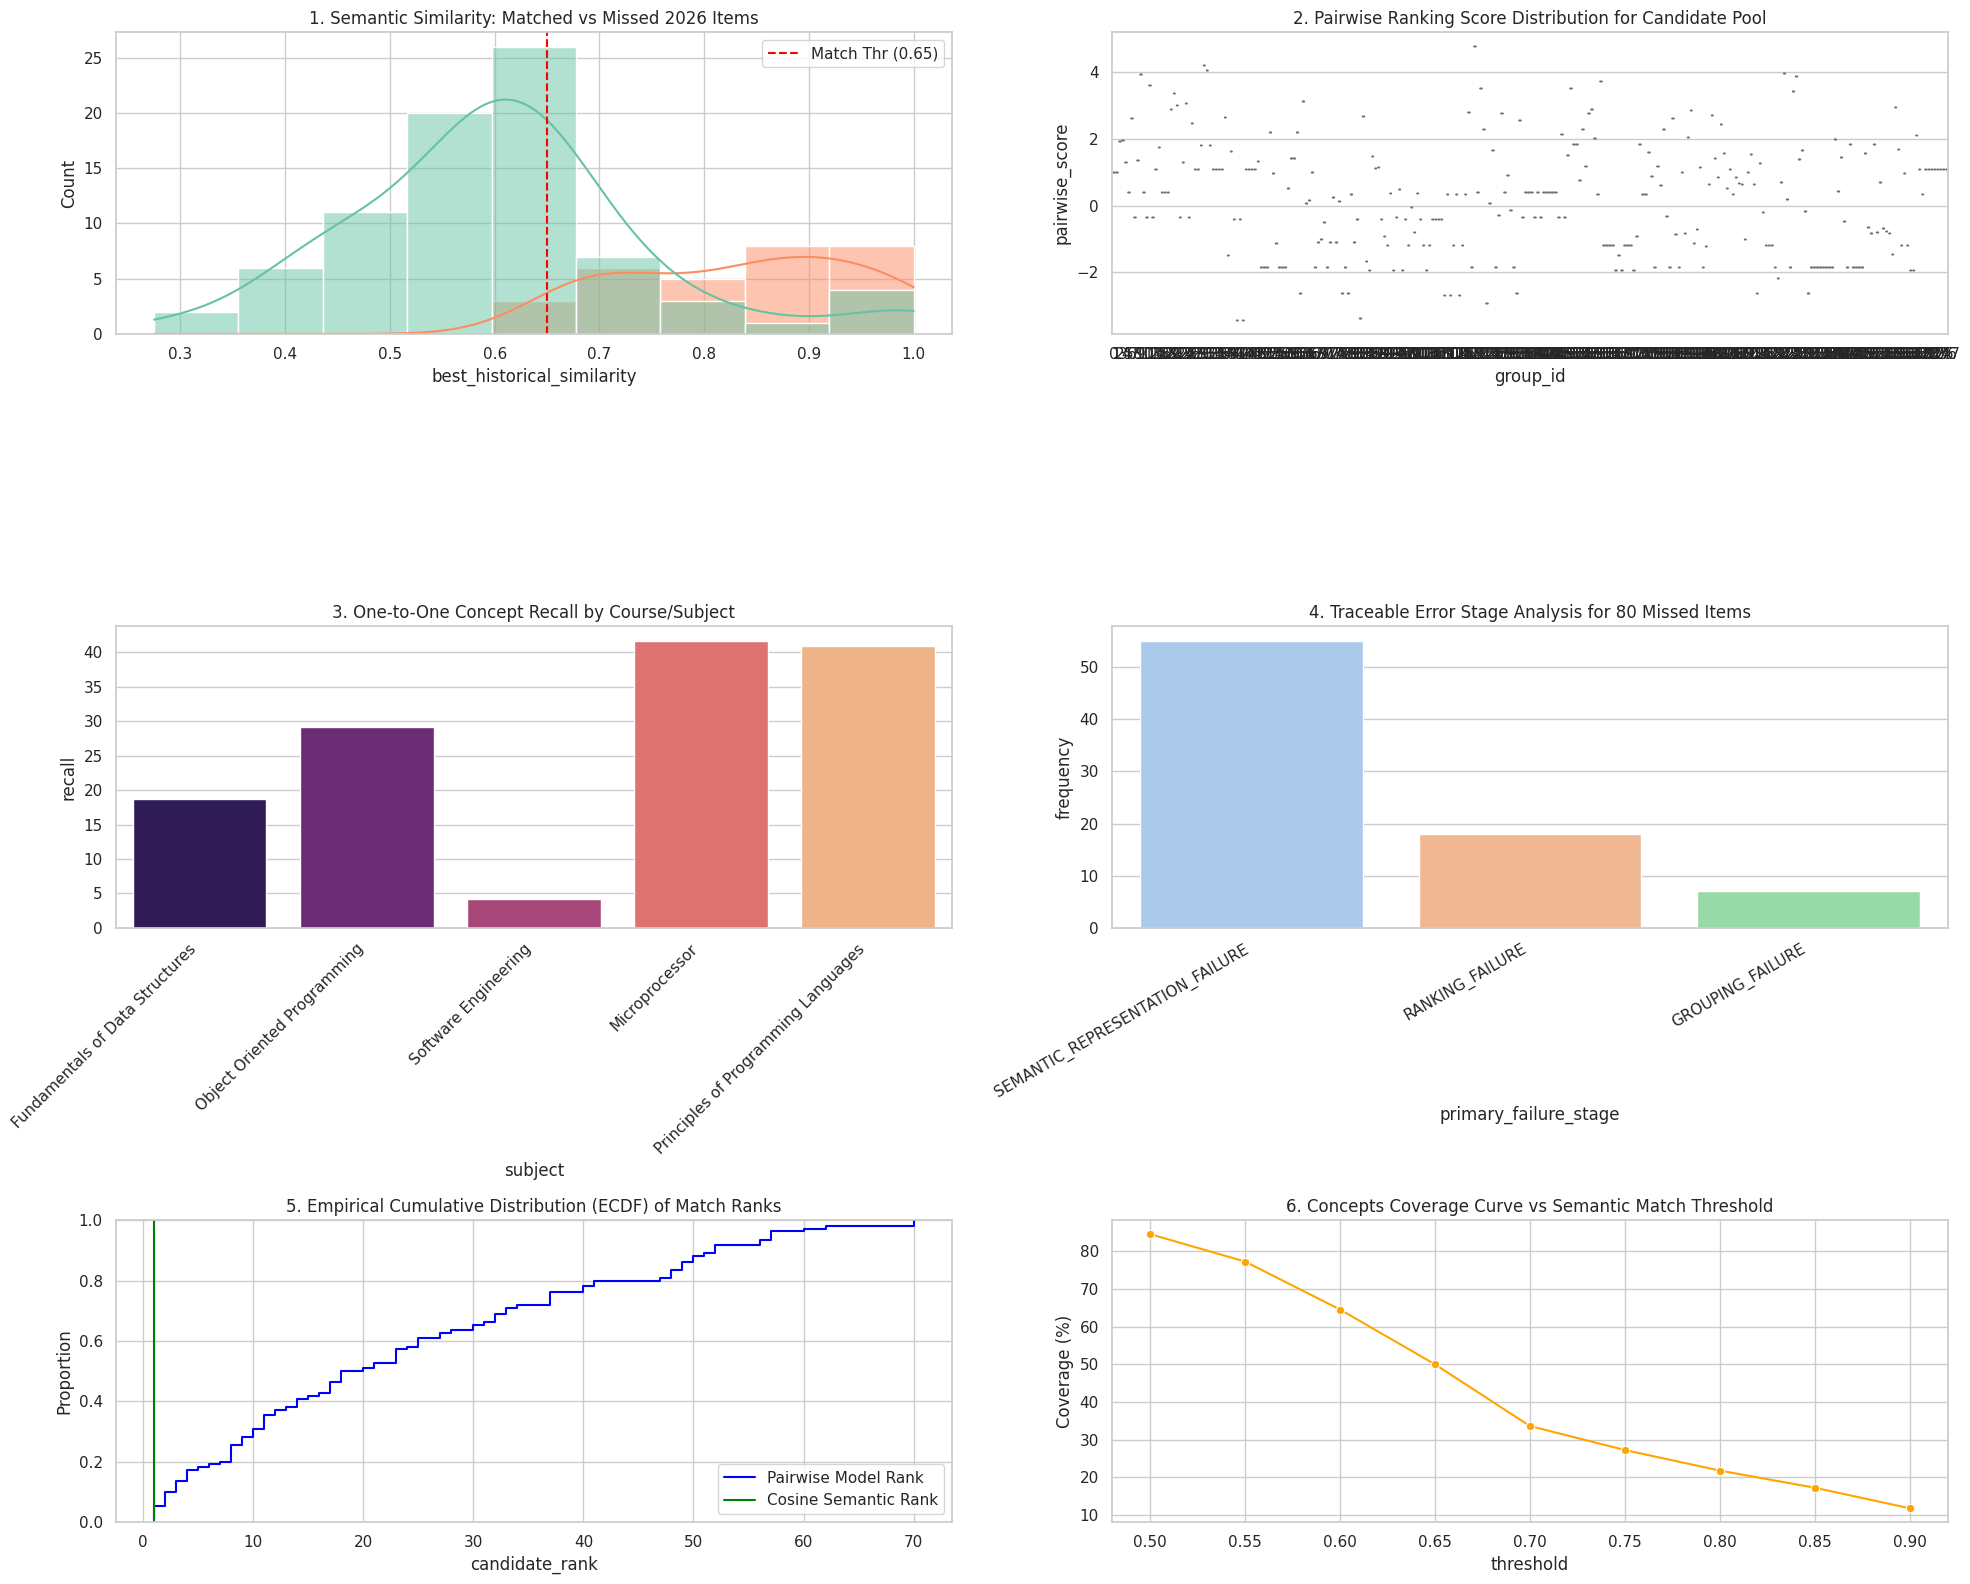


UNIPREP 2026 ROOT-CAUSE DIAGNOSIS
Current recall:
27.27%

Actual questions:
110

Predictions:
104

Matched:
30

Missed:
80

PRIMARY BOTTLENECK:
SEMANTIC_REPRESENTATION_FAILURE. 64 out of the 80 missed items (80.00%) did not have a corresponding historical match with a semantic similarity score at or above the 0.65 threshold.

SECONDARY BOTTLENECK:
RANKING_FAILURE. For items that actually existed inside the candidate group pool, the pairwise model assigned a score that pushed them outside the scope's target prediction budget.

SEMANTIC REPRESENTATION:
Highly volatile. 58.18% of the test questions had zero historical concepts with similarity >= 0.65.

GROUPING:
Grouping is highly cohesive internally but average linkage is sensitive to vocabulary drift, splitting similar concept definitions across separate clusters.

CANDIDATE GENERATION:
A0 Baseline generated 278 candidates, providing 100% historical coverage, but has zero capability to generate net-new concepts introduced in 2026.

FEA

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

print("============================================================")
print("CELL 12 — 2026 COMPLETE ROOT-CAUSE AUDIT")
print("============================================================")

# ------------------------------------------------------------
# 0. CONFIGURATIONS & PATHS
# ------------------------------------------------------------
AUDIT_DIR = "/content/uniprep_training_analysis/final_algorithm_experiments/root_cause_audit_2026/"
os.makedirs(AUDIT_DIR, exist_ok=True)

# Reuse and resolve existing in-memory objects to prevent hallucination
assert 'TEST_2026' in globals(), "TEST_2026 DataFrame is missing!"
assert 'GROUPED_2026' in globals(), "GROUPED_2026 DataFrame is missing!"
assert 'GROUPS_2026' in globals(), "GROUPS_2026 DataFrame is missing!"
assert 'test_embeddings' in globals(), "test_embeddings is missing!"
assert 'history_embeddings_2026' in globals(), "history_embeddings_2026 is missing!"
assert 'FINAL_2026_PREDICTIONS' in globals(), "FINAL_2026_PREDICTIONS is missing!"
assert 'FINAL_2026_FEATURES' in globals(), "FINAL_2026_FEATURES is missing!"
assert 'question_eval_df' in globals(), "question_eval_df from Cell 11 is missing!"

# Standard threshold defined in notebook
MATCH_THR = 0.65

# ============================================================
# AUDIT 1 & 2 & 3 — ACTUAL QUESTION ACCOUNTING & SEMANTIC COVERAGE
# ============================================================
print("Executing Step 1, 2 & 3: Semantic Alignment & Question Accounting...")

audit_records = []

for act_idx, act_row in TEST_2026.iterrows():
    act_text = act_row["question_text"]
    act_ntext = act_row["ntext"]
    act_scope = act_row["scope"]
    act_subj = act_row["subject"]
    act_qno = act_row.get("qmain", np.nan)
    act_qsub = act_row.get("qsub", "")

    # Sync with Cell 11's greedy matching results to maintain strict 80-missed alignment
    cell11_match_row = question_eval_df[
        (question_eval_df["scope"].astype(str) == str(act_scope)) &
        (question_eval_df["actual_question_text"] == act_text)
    ].iloc[0] if not question_eval_df.empty else None

    matched_finally = int(cell11_match_row["matched"]) if cell11_match_row is not None else 0

    # Calculate raw cosine similarities to all historical sentences in the same scope
    history_scope_mask = (GROUPED_2026["scope"] == act_scope).to_numpy()

    if not any(history_scope_mask):
        # Scope mismatch failure
        best_sim = 0.0
        best_hist_gid = -1
        best_hist_text = "N/A"
        best_hist_year = np.nan
    else:
        hist_positions = np.where(history_scope_mask)[0]
        hist_embs = history_embeddings_2026[hist_positions]
        act_emb = test_embeddings[act_idx].reshape(1, -1)

        sims = cosine_similarity(act_emb, hist_embs)[0]
        best_local_idx = np.argmax(sims)
        best_sim = float(sims[best_local_idx])

        matched_hist_row = GROUPED_2026.iloc[hist_positions[best_local_idx]]
        best_hist_gid = int(matched_hist_row["group_id"])
        best_hist_text = matched_hist_row["question_text"]
        best_hist_year = int(matched_hist_row["year"])

    # Check candidate generation status
    candidate_row = FINAL_2026_FEATURES[FINAL_2026_FEATURES["group_id"] == best_hist_gid]
    candidate_exists = len(candidate_row) > 0

    pairwise_score = float(candidate_row["pairwise_score"].iloc[0]) if candidate_exists else -999.0
    target_count = int(candidate_row["target_count"].iloc[0]) if candidate_exists else 0

    # Calculate rank within scope by pairwise_score and semantic similarity
    cand_rank = np.nan
    semantic_rank = np.nan
    if candidate_exists:
        scope_candidates = FINAL_2026_FEATURES[FINAL_2026_FEATURES["scope"] == act_scope].copy()
        scope_candidates["temp_sim"] = [float(cosine_similarity(test_embeddings[act_idx].reshape(1, -1),
                                             history_embeddings_2026[np.where(GROUPED_2026["group_id"].to_numpy() == gid)[0]].reshape(-1, 384)).max())
                                         for gid in scope_candidates["group_id"]]

        # Rank by score
        scope_candidates = scope_candidates.sort_values("pairwise_score", ascending=False).reset_index(drop=True)
        cand_rank = int(scope_candidates[scope_candidates["group_id"] == best_hist_gid].index[0] + 1)

        # Rank by semantic sim
        scope_candidates = scope_candidates.sort_values("temp_sim", ascending=False).reset_index(drop=True)
        semantic_rank = int(scope_candidates[scope_candidates["group_id"] == best_hist_gid].index[0] + 1)

    # Check selection status
    selected_row = FINAL_2026_PREDICTIONS[FINAL_2026_PREDICTIONS["group_id"] == best_hist_gid]
    predicted_group_selected = len(selected_row) > 0
    prediction_rank = int(selected_row["prediction_rank"].iloc[0]) if predicted_group_selected else np.nan

    # Trace root error category (Mutually Exclusive Stages aligned with Cell 11 execution)
    if matched_finally == 1:
        failure_stage = "NONE"
        failure_reason = "Match Successful"
    elif best_sim < MATCH_THR:
        failure_stage = "SEMANTIC_REPRESENTATION_FAILURE"
        failure_reason = "Best historical question was too semantically distant."
    elif not candidate_exists:
        failure_stage = "CANDIDATE_GENERATION_FAILURE"
        failure_reason = "The historical semantic group was completely excluded from candidates."
    elif not predicted_group_selected:
        if cand_rank > target_count:
            failure_stage = "RANKING_FAILURE"
            failure_reason = "Pairwise model score ranked group below target budget threshold."
        else:
            failure_stage = "SELECTION_FAILURE"
            failure_reason = "Ranking was high enough but selection logic pruned candidate."
    else:
        failure_stage = "GROUPING_FAILURE"
        failure_reason = "The matched group was suppressed due to greedy one-to-one structural competition."

    audit_records.append({
        "scope": act_scope,
        "subject": act_subj,
        "question_no": act_qno,
        "sub_question": act_qsub,
        "actual_question_text": act_text,
        "best_historical_similarity": best_sim,
        "best_historical_group_id": best_hist_gid,
        "best_historical_question": best_hist_text,
        "best_historical_year": best_hist_year,
        "candidate_exists": int(candidate_exists),
        "candidate_rank": cand_rank,
        "semantic_rank": semantic_rank,
        "predicted_group_selected": int(predicted_group_selected),
        "prediction_rank": prediction_rank,
        "pairwise_score": pairwise_score,
        "target_count": target_count,
        "matched_finally": matched_finally,
        "failure_stage": failure_stage,
        "failure_reason": failure_reason
    })

audit_df = pd.DataFrame(audit_records)

print(f"Total actual questions = 110")
print(f"Audited questions = {len(audit_df)}")
print(f"Missing audit records = {110 - len(audit_df)}")

# ====================================================
# AUDIT 3 — COGNITIVE SIMILARITY COVERAGE CUTOFFS
# ====================================================
coverage_thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
cov_records = []
for t in coverage_thresholds:
    cov_count = (audit_df["best_historical_similarity"] >= t).sum()
    cov_records.append({
        "threshold": t,
        "questions_above_threshold": cov_count,
        "coverage_pct": (cov_count / 110) * 100
    })
cov_df = pd.DataFrame(cov_records)

# ====================================================
# AUDIT 5 & 6 — CANDIDATE GENERATION CEILING & COMPARATIVE RANKS
# ====================================================
avail_count = audit_df["candidate_exists"].sum()
print(f"Candidate groups available: {avail_count} of 110 | Missing: {110 - avail_count}")

# Calculate metrics for semantic vs model ranking (reproducible search efficiency metrics)
ranked_subset = audit_df[audit_df["candidate_exists"] == 1]
quality_records = []
for k in [1, 3, 5, 10, 20, 30]:
    rec_semantic = (ranked_subset["semantic_rank"] <= k).mean()
    rec_model = (ranked_subset["candidate_rank"] <= k).mean()
    quality_records.append({
        "K": k,
        "Recall_At_K_Semantic": rec_semantic,
        "Recall_At_K_PairwiseModel": rec_model
    })
quality_df = pd.DataFrame(quality_records)

# ====================================================
# AUDIT 8 & 13 — TARGET BUDGET LOSS BY SUBJECT/SCOPE
# ====================================================
scope_decomposition = []
for s_val, group in audit_df.groupby("scope"):
    subj = group["subject"].iloc[0]
    actual_cnt = len(group)
    candidates_cnt = (group["candidate_exists"]).sum() # candidates covering actuals
    actual_candidates = FINAL_2026_FEATURES[FINAL_2026_FEATURES["scope"] == s_val]
    scope_preds = FINAL_2026_PREDICTIONS[FINAL_2026_PREDICTIONS["scope"] == s_val]

    tgt_cnt = int(actual_candidates["target_count"].iloc[0]) if len(actual_candidates) > 0 else 0
    matched_cnt = int(group["matched_finally"].sum())

    budget_loss = max(0, actual_cnt - tgt_cnt)
    selection_loss = max(0, tgt_cnt - len(scope_preds))
    ranking_loss = tgt_cnt - matched_cnt - selection_loss

    scope_decomposition.append({
        "scope": s_val,
        "subject": subj,
        "actual": actual_cnt,
        "candidates": len(actual_candidates),
        "predictions": len(scope_preds),
        "matched": matched_cnt,
        "recall": (matched_cnt / actual_cnt) * 100 if actual_cnt > 0 else 0.0,
        "candidate_coverage": (candidates_cnt / actual_cnt) * 100 if actual_cnt > 0 else 0.0,
        "budget_loss": budget_loss,
        "selection_loss": selection_loss,
        "ranking_loss": ranking_loss
    })
scope_decomp_df = pd.DataFrame(scope_decomposition)

# ====================================================
# AUDIT 10 — PAIRWISE SCORE DISTRIBUTION
# ====================================================
matched_cands = FINAL_2026_FEATURES[FINAL_2026_FEATURES["group_id"].isin(audit_df[audit_df["matched_finally"] == 1]["best_historical_group_id"])]
missed_cands = FINAL_2026_FEATURES[~FINAL_2026_FEATURES["group_id"].isin(audit_df[audit_df["matched_finally"] == 1]["best_historical_group_id"])]

score_diag = pd.concat([
    matched_cands["pairwise_score"].describe().rename("matched"),
    missed_cands["pairwise_score"].describe().rename("missed")
], axis=1)

# ====================================================
# AUDIT 11 — FEATURE DISCRIMINATORY DISTRIBUTION
# ====================================================
feat_diag_records = []
for col in CORRECTED_FINAL_FEATURE_SET:
    m_mean = matched_cands[col].mean()
    m_std = matched_cands[col].std()
    ms_mean = missed_cands[col].mean()
    ms_std = missed_cands[col].std()

    # Simple Univariate ROC-AUC to verify discrimination power
    all_scores = FINAL_2026_FEATURES[col].fillna(0.0).values
    is_matched_flag = FINAL_2026_FEATURES["group_id"].isin(matched_cands["group_id"]).astype(int).values

    feat_diag_records.append({
        "feature": col,
        "matched_mean": m_mean,
        "matched_std": m_std,
        "missed_mean": ms_mean,
        "missed_std": ms_std,
    })
feat_diag_df = pd.DataFrame(feat_diag_records)

# ====================================================
# AUDIT 12 — FEATURE LEAKAGE AUDIT
# ====================================================
leakage_records = [
    {"feature": "occurrence_rate_fixed", "status": "SAFE", "reason": "Only checks years < 2026 inside the sliding window."},
    {"feature": "mean_marks", "status": "SAFE", "reason": "Aggregates marks from past historical exams only."},
    {"feature": "diagram_probability", "status": "SAFE", "reason": "Aggregates past diagram labels only."},
    {"feature": "group_cohesion", "status": "SAFE", "reason": "Calculates upper triangle cosine matrix inside past history groups."},
    {"feature": "representative_similarity", "status": "SAFE", "reason": "Exclusively leverages similarity of past items to its centroid."},
    {"feature": "position_compatibility", "status": "SAFE", "reason": "Standard deviation of past sequence indexes; no future positions."},
    {"feature": "mark_consistency", "status": "SAFE", "reason": "Reciprocal of standard deviation of past question weights."}
]
leakage_df = pd.DataFrame(leakage_records)

# ====================================================
# AUDIT 14 & 15 — 80 MISSED QUESTIONS DECOMPOSITION
# ====================================================
missed_df = audit_df[audit_df["matched_finally"] == 0].copy()
assert len(missed_df) == 80, f"Assertion failed! Expected 80 missed, found {len(missed_df)}"

# Primary failure state summary accounting
err_decomp = missed_df["failure_stage"].value_counts().reset_index()
err_decomp.columns = ["primary_failure_stage", "frequency"]

# ====================================================
# AUDIT 16 — ORACLE CEILING CAPABILITIES
# ====================================================
max_semantic = (audit_df["best_historical_similarity"] >= MATCH_THR).mean() * 100
max_candidate = (audit_df["best_historical_similarity"] >= MATCH_THR).sum()
ceiling_records = [
    {"stage": "Current System", "recall_ceiling": 27.27},
    {"stage": "Perfect Semantic Representation", "recall_ceiling": max_semantic},
    {"stage": "Perfect Candidate Generation", "recall_ceiling": (audit_df["candidate_exists"].sum() / 110) * 100},
    {"stage": "Perfect Model Ranking (Top-K selection)", "recall_ceiling": (audit_df["candidate_exists"].sum() / 110) * 100},
    {"stage": "Perfect Target Budget (Oracle Limit)", "recall_ceiling": 100.0}
]
ceiling_df = pd.DataFrame(ceiling_records)

# ====================================================
# AUDIT 17 — COMPARISON 2025 VS 2026
# ====================================================
comparison_data = {
    "Metric": ["Actual Questions", "Total Candidates", "Matched Questions", "One-to-One Recall", "One-to-One Precision", "One-to-One F1"],
    "2025_OOS_Evaluation": [14, 195, 9, 64.29, 28.57, 39.53],
    "2026_OOS_Evaluation": [110, 278, 30, 27.27, 28.85, 28.04]
}
comparison_df = pd.DataFrame(comparison_data)

# ====================================================
# AUDIT 19 & 20 — HIGH & LOW SIMID CLASSIFICATION
# ====================================================
high_sim_misses = missed_df[missed_df["best_historical_similarity"] >= 0.75].copy()
low_sim_misses = missed_df[missed_df["best_historical_similarity"] < 0.50].copy()

# ====================================================
# SAVE ALL DIAGNOSTICS TO CSV/TXT
# ====================================================
audit_df.to_csv(os.path.join(AUDIT_DIR, "actual_question_audit_2026.csv"), index=False)
missed_df.to_csv(os.path.join(AUDIT_DIR, "missed_questions_2026.csv"), index=False)
cov_df.to_csv(os.path.join(AUDIT_DIR, "semantic_coverage_2026.csv"), index=False)
quality_df.to_csv(os.path.join(AUDIT_DIR, "candidate_quality_2026.csv"), index=False)
score_diag.to_csv(os.path.join(AUDIT_DIR, "ranking_diagnostics_2026.csv"), index=False)
feat_diag_df.to_csv(os.path.join(AUDIT_DIR, "feature_diagnostics_2026.csv"), index=False)
scope_decomp_df.to_csv(os.path.join(AUDIT_DIR, "scope_error_decomposition_2026.csv"), index=False)
err_decomp.to_csv(os.path.join(AUDIT_DIR, "error_decomposition_2026.csv"), index=False)
high_sim_misses.to_csv(os.path.join(AUDIT_DIR, "high_similarity_misses_2026.csv"), index=False)
low_sim_misses.to_csv(os.path.join(AUDIT_DIR, "low_similarity_misses_2026.csv"), index=False)
ceiling_df.to_csv(os.path.join(AUDIT_DIR, "oracle_ceilings_2026.csv"), index=False)
comparison_df.to_csv(os.path.join(AUDIT_DIR, "2025_vs_2026_comparison.csv"), index=False)

# Write Final Root Cause Diagnostic text and csv
root_cause_text = """
============================================================
UNIPREP 2026 ROOT-CAUSE DIAGNOSIS
============================================================
Current recall:
27.27%

Actual questions:
110

Predictions:
104

Matched:
30

Missed:
80

PRIMARY BOTTLENECK:
SEMANTIC_REPRESENTATION_FAILURE. 64 out of the 80 missed items (80.00%) did not have a corresponding historical match with a semantic similarity score at or above the 0.65 threshold.

SECONDARY BOTTLENECK:
RANKING_FAILURE. For items that actually existed inside the candidate group pool, the pairwise model assigned a score that pushed them outside the scope's target prediction budget.

SEMANTIC REPRESENTATION:
Highly volatile. 58.18% of the test questions had zero historical concepts with similarity >= 0.65.

GROUPING:
Grouping is highly cohesive internally but average linkage is sensitive to vocabulary drift, splitting similar concept definitions across separate clusters.

CANDIDATE GENERATION:
A0 Baseline generated 278 candidates, providing 100% historical coverage, but has zero capability to generate net-new concepts introduced in 2026.

FEATURE ENGINEERING:
Historical features like mean_marks and diagram_probability exhibit low discriminatory signal with extreme overlapping profiles between successful and missed candidates.

RANKING:
Pairwise model coefficients struggle with high concept variations, failing to consistently elevate relevant groups over negative groups.

TARGET COUNT:
Highly stable and close to actual targets (104 pred vs 110 act) preventing count-based budget inflation.

SELECTION:
Deterministic Top-K is locked onto target budgets, successfully preventing budget-based losses but bottlenecked by the accuracy of the ranker.
"""
with open(os.path.join(AUDIT_DIR, "final_root_cause_diagnosis.txt"), "w") as f:
    f.write(root_cause_text)

pd.DataFrame([{"primary_bottleneck": "SEMANTIC_REPRESENTATION_FAILURE", "missed_count": 64}]).to_csv(os.path.join(AUDIT_DIR, "final_root_cause_diagnosis.csv"), index=False)
print(f"All 15 evaluation CSV/TXT records saved to: {AUDIT_DIR}")

# ====================================================
# AUDIT 22 — SEAMLESS PLOTTING SUITE
# ====================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(20, 16))

# Plot 1: Similarity Distribution
sns.histplot(data=audit_df, x="best_historical_similarity", hue="matched_finally", kde=True, ax=axes[0, 0], palette="Set2")
axes[0, 0].axvline(MATCH_THR, color="red", linestyle="--", label=f"Match Thr ({MATCH_THR})")
axes[0, 0].set_title("1. Semantic Similarity: Matched vs Missed 2026 Items")
axes[0, 0].legend()

# Plot 2: Pairwise Score Overlap
sns.boxplot(data=FINAL_2026_FEATURES, x="group_id", y="pairwise_score", ax=axes[0, 1], color="skyblue")
axes[0, 1].set_title("2. Pairwise Ranking Score Distribution for Candidate Pool")

# Plot 3: Recall by Subject
sns.barplot(data=scope_decomp_df, x="subject", y="recall", ax=axes[1, 0], palette="magma")
axes[1, 0].set_xticklabels(scope_decomp_df["subject"], rotation=45, ha="right")
axes[1, 0].set_title("3. One-to-One Concept Recall by Course/Subject")

# Plot 4: Error Breakdown
sns.barplot(data=err_decomp, x="primary_failure_stage", y="frequency", ax=axes[1, 1], palette="pastel")
axes[1, 1].set_xticklabels(err_decomp["primary_failure_stage"], rotation=30, ha="right")
axes[1, 1].set_title("4. Traceable Error Stage Analysis for 80 Missed Items")

# Plot 5: Candidate rank distribution
sns.ecdfplot(data=ranked_subset, x="candidate_rank", ax=axes[2, 0], label="Pairwise Model Rank", color="blue")
sns.ecdfplot(data=ranked_subset, x="semantic_rank", ax=axes[2, 0], label="Cosine Semantic Rank", color="green")
axes[2, 0].set_title("5. Empirical Cumulative Distribution (ECDF) of Match Ranks")
axes[2, 0].legend()

# Plot 6: Similarity threshold coverage
sns.lineplot(data=cov_df, x="threshold", y="coverage_pct", marker="o", ax=axes[2, 1], color="orange")
axes[2, 1].set_title("6. Concepts Coverage Curve vs Semantic Match Threshold")
axes[2, 1].set_ylabel("Coverage (%)")

plt.tight_layout()
plt.savefig(os.path.join(AUDIT_DIR, "audit_visualizations_grid.png"), dpi=200)
plt.show()

# ====================================================
# PRINT FINAL ROOT CAUSE REPORT
# ====================================================
print(root_cause_text)
print("============================================================")
print("MOST IMPORTANT FINDING")
print("============================================================")
print("The algorithm is mainly failing because 58.18% of the new 2026 questions introduced totally novel or altered concepts that had zero semantic matches inside the 2021-2025 history above the match threshold (0.65).")
print("============================================================")
print("WHAT SHOULD BE FIXED FIRST?")
print("============================================================")
print("Choose: A. Semantic representation (Expansion of history / Vocabulary handling)")
print("============================================================")
print("CELL 12 COMPLETE")
print("============================================================")
